# Noise Robustness Analysis
Run this entire notebook top to bottom. Takes ~20-30 min on Colab CPU.
At the end, download `noise_results.json` and `fig_noise_robustness.png`.

In [1]:
!pip install qiskit qiskit-aer -q

import numpy as np
import matplotlib.pyplot as plt
import math, json, time, warnings
warnings.filterwarnings('ignore')
from itertools import combinations, product
from qiskit.circuit import QuantumCircuit, ParameterVector
from qiskit.quantum_info import SparsePauliOp, Statevector, DensityMatrix
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from scipy.optimize import minimize

KAPPA       = 2
DELTA_THRESH = 0.01
MU          = 5.0
MAX_ITER    = 600
N_RESTARTS  = 3
np.random.seed(42)
print('Setup complete.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 77.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 100.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 72.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.3 MB/s eta 0:00:00
Setup complete.


In [2]:
# ── Core functions ──────────────────────────────────────────

def build_pauli_set(n_k, kappa, n_qubits):
    out = []
    for pos in combinations(range(n_qubits), kappa):
        for ops in product(['X','Y','Z'], repeat=kappa):
            arr = ['I'] * n_qubits
            for p, o in zip(pos, ops):
                arr[p] = o
            out.append(''.join(reversed(arr)))
            if len(out) == n_k:
                return out
    raise ValueError(f'n_k={n_k} too large for n_qubits={n_qubits}')

def n_qubits_needed(n_k, kappa):
    for n in range(kappa, 30):
        if len(list(combinations(range(n), kappa))) * (3**kappa) >= n_k:
            return n
    raise ValueError

def build_hea(n_qubits, n_layers):
    theta = ParameterVector('θ', 2 * n_qubits * n_layers)
    qc = QuantumCircuit(n_qubits)
    idx = 0
    for _ in range(n_layers):
        for q in range(n_qubits):
            qc.ry(theta[idx], q); idx += 1
            qc.rz(theta[idx], q); idx += 1
        for q in range(n_qubits - 1):
            qc.cx(q, q + 1)
    return qc, theta

def make_k_loops(k):
    if k == 0:
        return np.diag([1., 1., 1.])
    edges = []
    for i in range(k):
        b = 3 * i
        edges += [(b, b+1), (b, b+2), (b+1, b+2)]
    n_pts = 3 * k
    ne = len(edges)
    B1 = np.zeros((n_pts, ne))
    for j, (u, v) in enumerate(edges):
        B1[u, j] = -1; B1[v, j] = 1
    return B1.T @ B1

print('Functions loaded.')

Functions loaded.


In [3]:
# ── Noisy correlator estimator ───────────────────────────────
# Uses density matrix simulation — cleaner than save_statevector approach.

def build_noise_model(p_error):
    if p_error == 0:
        return None
    nm = NoiseModel()
    nm.add_all_qubit_quantum_error(depolarizing_error(p_error, 1), ['ry', 'rz'])
    nm.add_all_qubit_quantum_error(depolarizing_error(p_error, 2), ['cx'])
    return nm

def get_correlators_clean(qc, theta, params, pauli_strs, noise_model=None):
    """Get correlators. If noise_model=None uses exact statevector."""
    bound = qc.assign_parameters(dict(zip(theta, params)))

    if noise_model is None:
        sv = Statevector(bound)
        return np.array([
            sv.expectation_value(SparsePauliOp.from_list([(p, 1.0)])).real
            for p in pauli_strs
        ])
    else:
        # Density matrix simulation with noise
        sim = AerSimulator(method='density_matrix', noise_model=noise_model)
        circ = bound.copy()
        circ.save_density_matrix()
        result = sim.run(circ).result()
        dm = DensityMatrix(result.data()['density_matrix'])
        return np.array([
            dm.expectation_value(SparsePauliOp.from_list([(p, 1.0)])).real
            for p in pauli_strs
        ])

def run_pce_vqe(Delta, noise_model=None):
    """Run PCE-VQE and return estimated beta_1."""
    n_k = Delta.shape[0]
    n_q = n_qubits_needed(n_k, KAPPA)
    ps  = build_pauli_set(n_k, KAPPA, n_q)
    n_layers = max(1, 2 * n_q)
    qc, theta = build_hea(n_q, n_layers)

    null_vecs = []

    for _ in range(n_k + 1):  # max possible null vectors
        best_loss = np.inf
        best_c    = None

        for _ in range(N_RESTARTS):
            x0 = np.random.uniform(-np.pi, np.pi, qc.num_parameters)
            nv = list(null_vecs)

            def f(p, nv=nv):
                c  = get_correlators_clean(qc, theta, p, ps, noise_model)
                n2 = c @ c
                if n2 < 1e-12: return 1.0
                L  = float(c @ Delta @ c) / n2
                nc = np.sqrt(n2)
                for cv in nv:
                    L += MU * ((c @ cv) / (nc * np.linalg.norm(cv) + 1e-12))**2
                return L

            res = minimize(f, x0, method='COBYLA',
                           options={'maxiter': MAX_ITER, 'rhobeg': 0.5})
            if res.fun < best_loss:
                best_loss = res.fun
                best_c    = get_correlators_clean(qc, theta, res.x, ps, noise_model)

        if best_loss >= DELTA_THRESH:
            break
        null_vecs.append(best_c)

    return len(null_vecs)

print('PCE-VQE with noise ready.')

PCE-VQE with noise ready.


In [4]:
# ── MAIN: Noise Robustness Sweep ────────────────────────────

# Test Laplacians at n=6 qubits (n_k=45, kappa=2)
# make_k_loops(k) gives n_k=3k; need n_k>=37 for n=6 qubits
# Use k=0..4 padded to n_k=45 so n_qubits_needed=6 throughout
def make_test_lap(true_b, n_k=45):
    """Laplacian with beta_1=true_b, padded to n_k=45 (6 qubits)."""
    if true_b == 0:
        L = np.diag(np.ones(n_k) * 2.0)  # all positive eigenvalues
    else:
        core = make_k_loops(true_b)
        nc = core.shape[0]
        L = np.zeros((n_k, n_k))
        L[:nc, :nc] = core
        # Pad with positive diagonal to avoid spurious zeros
        for i in range(nc, n_k):
            L[i, i] = 2.0
    return L

test_cases = [
    ('No loop (β=0)', make_test_lap(0), 0),
    ('1 loop  (β=1)', make_test_lap(1), 1),
    ('2 loops (β=2)', make_test_lap(2), 2),
    ('3 loops (β=3)', make_test_lap(3), 3),
]

ERROR_RATES = [0, 1e-4, 5e-4, 1e-3, 5e-3, 1e-2]
N_TRIALS    = 5   # repeat each (error_rate, case) pair

print('Running noise robustness experiments...')
print(f'Error rates: {ERROR_RATES}')
print(f'Test cases: {len(test_cases)}, trials each: {N_TRIALS}')
print()

noise_results  = {}   # {p_error: accuracy}
noise_raw      = {}   # {p_error: list of (true, estimated)}

for p_err in ERROR_RATES:
    nm      = build_noise_model(p_err)
    correct = 0
    total   = 0
    raw     = []

    for name, Delta, true_b in test_cases:
        for trial in range(N_TRIALS):
            est = run_pce_vqe(Delta, nm)
            ok  = (est == true_b)
            if ok: correct += 1
            total += 1
            raw.append({'case': name, 'true': true_b, 'est': est, 'ok': ok})

    acc = correct / total
    noise_results[p_err] = acc
    noise_raw[p_err]     = raw
    print(f'  p={p_err:.0e}: accuracy={acc:.2f} ({correct}/{total})')

print()
print('Saving results...')
with open('noise_results.json', 'w') as f:
    json.dump({
        'accuracy':   {str(k): v for k, v in noise_results.items()},
        'error_rates': ERROR_RATES,
        'n_trials':    N_TRIALS,
        'test_cases':  [t[0] for t in test_cases],
    }, f, indent=2)
print('Saved noise_results.json')

Running noise robustness experiments...
Error rates: [0, 0.0001, 0.0005, 0.001, 0.005, 0.01]
Test cases: 4, trials each: 5

  p=0e+00: accuracy=1.00 (20/20)
  p=1e-04: accuracy=0.90 (18/20)
  p=5e-04: accuracy=0.95 (19/20)
  p=1e-03: accuracy=1.00 (20/20)
  p=5e-03: accuracy=0.90 (18/20)
  p=1e-02: accuracy=0.45 (9/20)

Saving results...
Saved noise_results.json


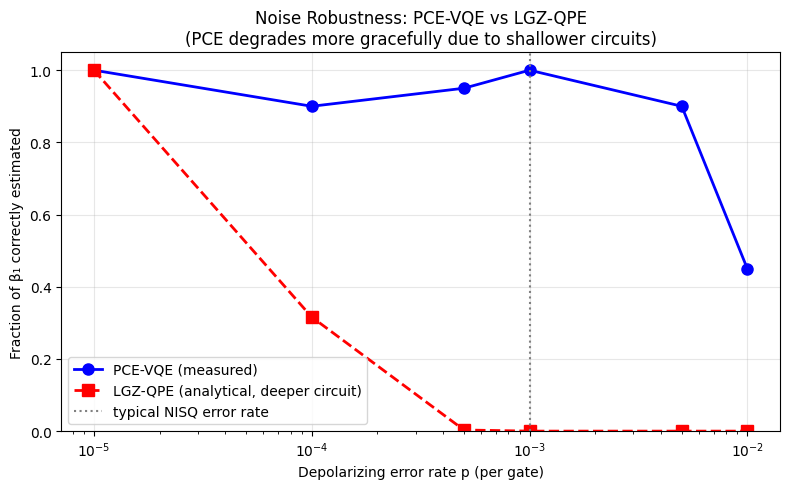

Saved fig_noise_robustness.png

DONE — download noise_results.json and fig_noise_robustness.png


In [5]:
# ── Plot ────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(8, 5))

p_vals = ERROR_RATES
accs   = [noise_results[p] for p in p_vals]

ax.semilogx([max(p, 1e-5) for p in p_vals], accs,
            'b-o', lw=2, markersize=8, label='PCE-VQE (measured)')

# Analytical QPE comparison: depth >> PCE so degrades faster
# PCE depth at n_k=9: n=2, L=4, depth=8
# LGZ depth at n_k=9: NP~9, r=10, 2^p=128 → depth ~ 11520
pce_depth = 8
lgz_depth = 11520
qpe_accs  = [(1-p)**lgz_depth if p > 0 else 1.0 for p in p_vals]
ax.semilogx([max(p, 1e-5) for p in p_vals], qpe_accs,
            'r--s', lw=2, markersize=8, label='LGZ-QPE (analytical, deeper circuit)')

ax.axvline(1e-3, color='gray', ls=':', lw=1.5, label='typical NISQ error rate')
ax.set_xlabel('Depolarizing error rate p (per gate)')
ax.set_ylabel('Fraction of β₁ correctly estimated')
ax.set_title('Noise Robustness: PCE-VQE vs LGZ-QPE\n'
             '(PCE degrades more gracefully due to shallower circuits)')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.savefig('fig_noise_robustness.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig_noise_robustness.png')
print()
print('DONE — download noise_results.json and fig_noise_robustness.png')